In [1]:
import pandas as pd
df=pd.read_csv("realestate_clean_file.csv")
df.head()

,enquiry_id,name,address,pin,mobile,alternate_number,email,lead_under_emp_id,lead_date,zone,building_id,building_number,status,followup_1_message,followup_date_1,followup_2_message,followup_date_2,followup_3,followup_date_3
0,ENQ000001,Geeta Joshi,"257, Jubilee Hills, Central Zone",452001,9527780790,8275387012,geeta.joshi62@yahoo.com,EMP0021,1/23/2026,Central,BLD026,Block Z,Followup 1,Price negotiation in progress,1/28/2026 0:00,No Followup,No Date,No Followup,No Date
1,ENQ000002,Pankaj Agarwal,"204, Indiranagar, South Zone",560003,9937850514,8449063037,pankaj.agarwal690@hotmail.com,EMP0027,11/14/2025,South,BLD004,Block D,Followup 2,Reminder call for site visit,11/16/2025 0:00,Sent floor plan and pricing details,11/23/2025,No Followup,No Date
2,ENQ000003,Sanjay Nair,"234, Connaught Place, East Zone",800001,9801167479,8387196293,sanjay.nair620@hotmail.com,EMP0005,12/23/2025,East,BLD003,Block C,Contacted,Price negotiation in progress,12/28/2025 0:00,No Followup,No Date,No Followup,No Date
3,ENQ000004,Sanjay Das,"106, Park Street, North Zone",110002,9608079376,8128309105,sanjay.das790@hotmail.com,EMP0006,5/10/2026,North,BLD007,Block G,New,No Followup,No Date,No Followup,No Date,No Followup,No Date
4,ENQ000005,Rakesh Choudhary,"642, Lajpat Nagar, South Zone",560003,9665585273,No Data,rakesh.choudhary30@gmail.com,EMP0016,3/1/2026,South,BLD024,Block X,Followup 2,Customer comparing with other properties,3/5/2026 0:00,Reminder call for site visit,3/11/2026,No Followup,No Date


In [2]:
import pandas as pd 
import matplotlib .pyplot as plt 
import seaborn as sns 
import plotly.express as px 

In [3]:
df.shape

(6000, 19)

In [4]:
df.columns

Index(['enquiry_id', 'name', 'address', 'pin', 'mobile', 'alternate_number',
       'email', 'lead_under_emp_id', 'lead_date', 'zone', 'building_id',
       'building_number', 'status', 'followup_1_message', 'followup_date_1',
       'followup_2_message', 'followup_date_2', 'followup_3',
       'followup_date_3'],
      dtype='str')

In [5]:
# Total Enquiry
total_enquiry = df['enquiry_id'].count()

# Total Zone
total_zone = df['zone'].nunique()

# Total Buildings
total_building = df['building_id'].nunique()

# Status Count
status_count = df['status'].value_counts()

print("Total Enquiry:", total_enquiry)
print("Total Zone:", total_zone)
print("Total Building:", total_building)

Total Enquiry: 6000
Total Zone: 5
Total Building: 26


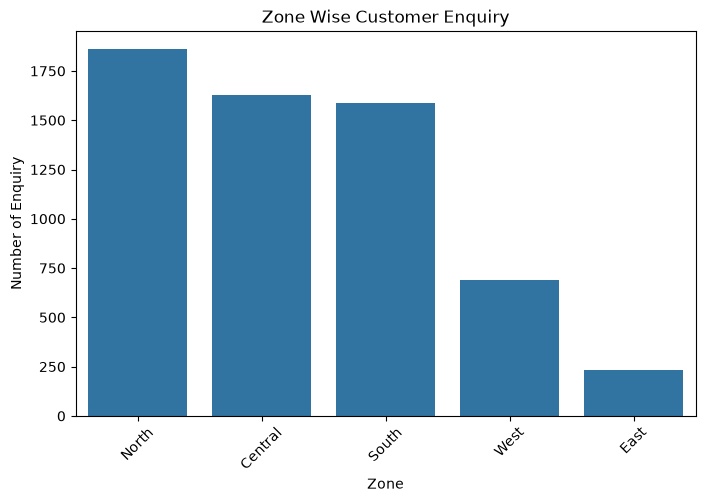

In [6]:
zone_data = df['zone'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=zone_data.index,
    y=zone_data.values
)

plt.title("Zone Wise Customer Enquiry")
plt.xlabel("Zone")
plt.ylabel("Number of Enquiry")
plt.xticks(rotation=45)
plt.show()

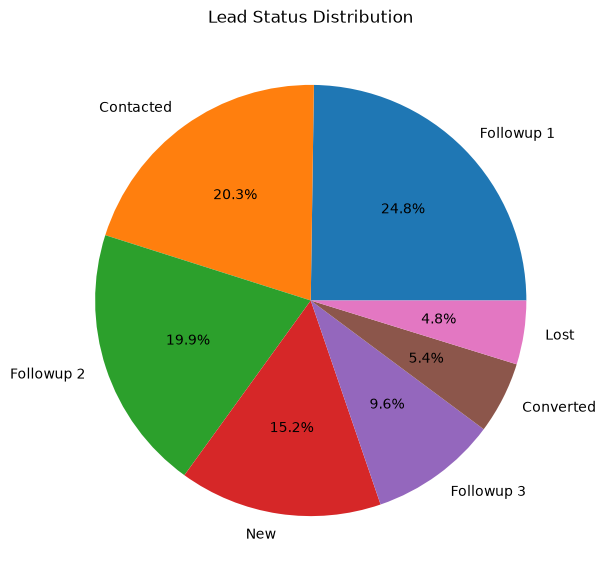

In [7]:
status_data = df['status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status_data.values,
    labels=status_data.index,
    autopct='%1.1f%%'
)

plt.title("Lead Status Distribution")
plt.show()

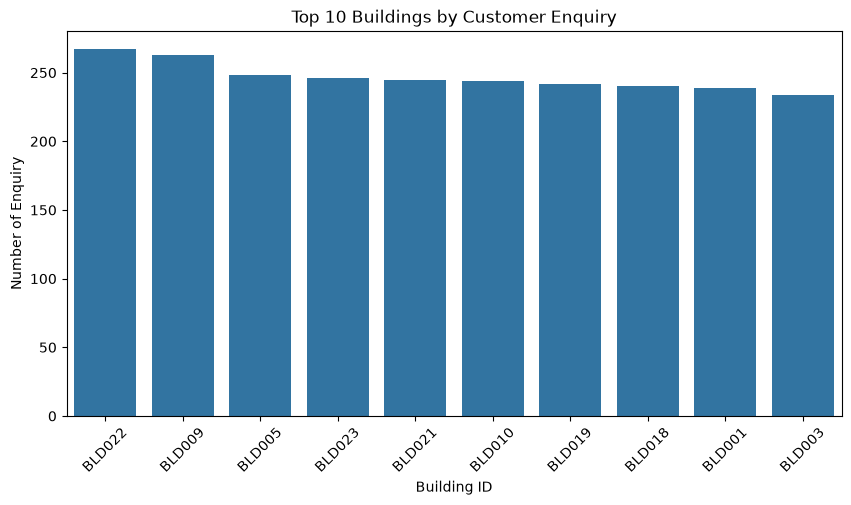

In [8]:
building_data = df['building_id'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=building_data.index,
    y=building_data.values
)

plt.title("Top 10 Buildings by Customer Enquiry")
plt.xlabel("Building ID")
plt.ylabel("Number of Enquiry")
plt.xticks(rotation=45)

plt.show()

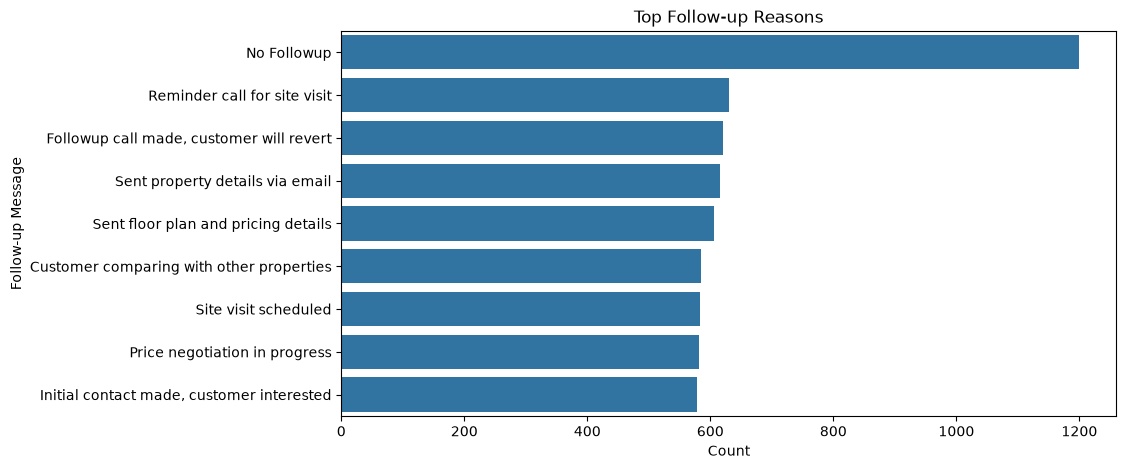

In [9]:
followup_data = df['followup_1_message'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=followup_data.values,
    y=followup_data.index
)

plt.title("Top Follow-up Reasons")
plt.xlabel("Count")
plt.ylabel("Follow-up Message")

plt.show()

In [10]:
df['lead_date'] = pd.to_datetime(df['lead_date'])

monthly_leads = df['lead_date'].dt.to_period('M').value_counts().sort_index()

monthly_leads

lead_date
2025-11     540
2025-12    1033
2026-01    1000
2026-02     943
2026-03    1012
2026-04    1034
2026-05     438
Freq: M, Name: count, dtype: int64

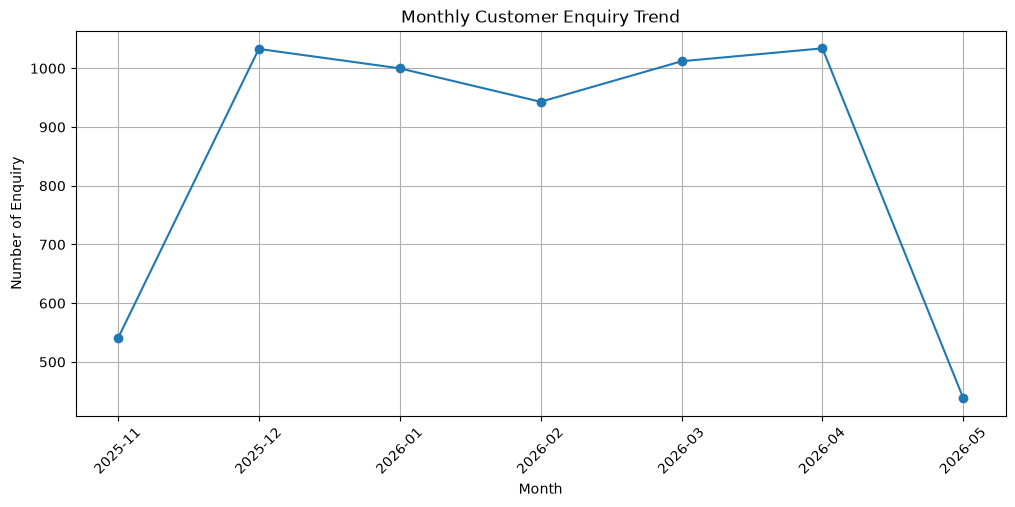

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_leads.index.astype(str),
    monthly_leads.values,
    marker='o'
)

plt.title("Monthly Customer Enquiry Trend")
plt.xlabel("Month")
plt.ylabel("Number of Enquiry")

plt.xticks(rotation=45)
plt.grid()

plt.show()

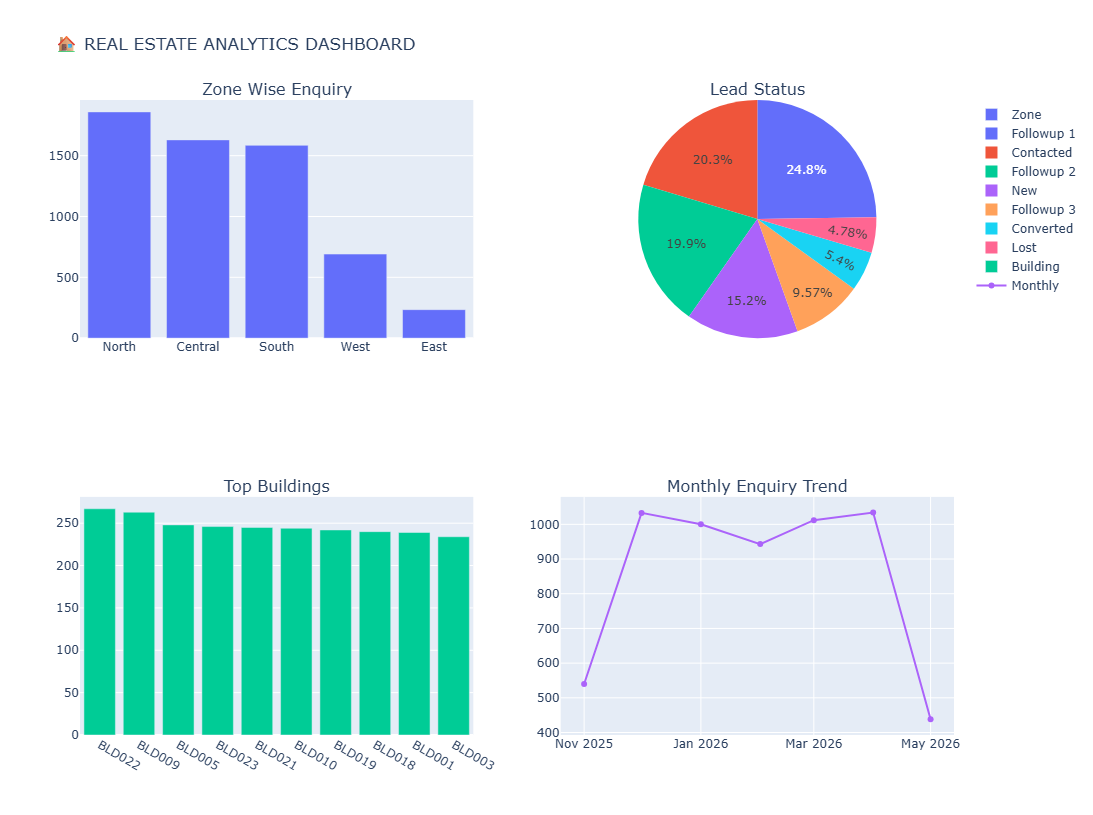

In [13]:
# Create Dashboard

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# KPI Values
total_enquiry = df['enquiry_id'].count()
total_zone = df['zone'].nunique()
total_building = df['building_id'].nunique()

# Data
zone_data = df['zone'].value_counts()
status_data = df['status'].value_counts()
building_data = df['building_id'].value_counts().head(10)


fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{"type":"bar"}, {"type":"pie"}],
        [{"type":"bar"}, {"type":"scatter"}]
    ],
    subplot_titles=(
        "Zone Wise Enquiry",
        "Lead Status",
        "Top Buildings",
        "Monthly Enquiry Trend"
    )
)


# Zone Chart
fig.add_trace(
    go.Bar(
        x=zone_data.index,
        y=zone_data.values,
        name="Zone"
    ),
    row=1,
    col=1
)


# Status Pie
fig.add_trace(
    go.Pie(
        labels=status_data.index,
        values=status_data.values,
        name="Status"
    ),
    row=1,
    col=2
)


# Building Chart
fig.add_trace(
    go.Bar(
        x=building_data.index,
        y=building_data.values,
        name="Building"
    ),
    row=2,
    col=1
)


# Monthly Trend
fig.add_trace(
    go.Scatter(
        x=monthly_leads.index.astype(str),
        y=monthly_leads.values,
        mode="lines+markers",
        name="Monthly"
    ),
    row=2,
    col=2
)


fig.update_layout(
    height=800,
    width=1200,
    title_text="🏠 REAL ESTATE ANALYTICS DASHBOARD"
)
monthly_leads=df['lead_date'].dt.to_period('M').value_counts().sort_index()
fig.show()